In [ ]:
# Install required libraries
!pip install -q torch torchvision torchaudio timm
!pip install -q transformers bitsandbytes accelerate
!pip install -q grad-cam opencv-python matplotlib

import torch
import torch.nn as nn
import timm
from torchvision import models, transforms
import cv2
import numpy as np
from PIL import Image
import os
from google.colab import drive
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline, BitsAndBytesConfig
from pytorch_grad_cam import GradCAMPlusPlus
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pytorch_grad_cam.utils.image import show_cam_on_image

# Mount Drive and Set Device
drive.mount('/content/drive')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_names = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']
print(f"✅ Using device: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 38.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Mounted at /content/drive
✅ Using device: cuda


data set

In [ ]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/Code for paper/brain.zip'
extract_path = '/content/dataset'

# Create directory if it doesn't exist and unzip
if not os.path.exists(extract_path):
    os.makedirs(extract_path)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        print("Extracting dataset to local runtime... please wait.")
        zip_ref.extractall(extract_path)
    print("✅ Extraction Complete.")
else:
    print("✅ Dataset already present.")

# Confirming the folders exist
val_path = os.path.join(extract_path, 'Val')
if os.path.exists(val_path):
    print(f"Folders in Val: {os.listdir(val_path)}")
else:
    # Check if there is a nested folder (sometimes zips extract into brain/Val)
    print("Checking for nested structures...")
    for root, dirs, files in os.walk(extract_path):
        if 'Val' in dirs:
            val_path = os.path.join(root, 'Val')
            print(f"Found Val at: {val_path}")
            break

✅ Dataset already present.
Folders in Val: ['Glioma', 'Meningioma', 'Pituitary', 'No Tumor']


model architecture

In [ ]:
class TripleAttentionFusion(nn.Module):
    def __init__(self, densenet, swin, vit, num_classes=4):
        super(TripleAttentionFusion, self).__init__()
        # DenseNet for CNN-based local spatial features
        self.densenet_feat = nn.Sequential(*list(densenet.children())[:-1], nn.AdaptiveAvgPool2d(1))
        self.swin_feat = swin
        self.vit_feat = vit
        self.proj_cnn = nn.Linear(1024, 512)
        self.proj_swin = nn.Linear(768, 512)
        self.proj_vit = nn.Linear(768, 512)
        self.multihead_attn = nn.MultiheadAttention(embed_dim=512, num_heads=8, batch_first=True)
        self.classifier = nn.Sequential(
            nn.Linear(512 * 3, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        feat_cnn = self.densenet_feat(x).flatten(1)
        feat_swin = self.swin_feat.forward_features(x)
        if len(feat_swin.shape) == 4: feat_swin = feat_swin.mean(dim=(1, 2))
        elif len(feat_swin.shape) == 3: feat_swin = feat_swin.mean(dim=1)
        feat_vit = self.vit_feat.forward_features(x)
        if len(feat_vit.shape) == 3: feat_vit = feat_vit[:, 0]

        p_cnn = self.proj_cnn(feat_cnn).unsqueeze(1)
        p_swin = self.proj_swin(feat_swin).unsqueeze(1)
        p_vit = self.proj_vit(feat_vit).unsqueeze(1)

        query = torch.cat([p_swin, p_vit], dim=1)
        attn_out, _ = self.multihead_attn(query, p_cnn, p_cnn)
        combined = torch.cat([p_cnn.squeeze(1), attn_out.reshape(x.size(0), -1)], dim=1)
        return self.classifier(combined)

loading weights and models

In [ ]:
# A. Re-load Vision Weights
d_backbone = models.densenet121(weights=None)
d_backbone.classifier = nn.Sequential(nn.Linear(1024, 512), nn.ReLU(), nn.Dropout(0.3), nn.Linear(512, 4))
s_backbone = timm.create_model('swin_tiny_patch4_window7_224', pretrained=False, num_classes=4)
s_backbone.head = nn.Sequential(nn.Linear(768, 512), nn.ReLU(), nn.Dropout(0.3), nn.Linear(512, 4))
v_backbone = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=4)

master_model = TripleAttentionFusion(d_backbone, s_backbone, v_backbone).to(device)
weights_path = '/content/drive/MyDrive/Code for paper/Final_TripleFusion_99Acc.pth'
master_model.load_state_dict(torch.load(weights_path, map_location=device))
master_model.eval()

# B. Set Grad-CAM (Targeting DenseNet backbone for spatial features)
target_layers = [master_model.densenet_feat[0][-1]]
cam = GradCAMPlusPlus(model=master_model, target_layers=target_layers)

print("✅ Vision and Grad-CAM synchronized.")

✅ Vision and Grad-CAM synchronized.


llm

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline, BitsAndBytesConfig

# 1. Wipe the buggy remote code cache one last time
!rm -rf /root/.cache/huggingface/modules/transformers_modules/microsoft

print("🔄 Loading Phi-3 using the STABLE internal library...")

# We use the base model ID but force the local implementation
model_id = "microsoft/Phi-3-mini-4k-instruct"

q_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

tokenizer = AutoTokenizer.from_pretrained(model_id)

# KEY CHANGE: trust_remote_code=False forces transformers to use its own
# internal, patched version of Phi-3 instead of downloading the buggy one.
llm_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=q_config,
    device_map="auto",
    trust_remote_code=False,
    attn_implementation="eager"
)

llm_pipeline = pipeline("text-generation", model=llm_model, tokenizer=tokenizer)

print("\n✅ SUCCESS! The LLM is loaded and the 'KeyError' is bypassed.")

🔄 Loading Phi-3 using the STABLE internal library...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]


✅ SUCCESS! The LLM is loaded and the 'KeyError' is bypassed.


In [ ]:
import os
import torch
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path # <--- THIS FIXES THE NAMEERROR
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline, BitsAndBytesConfig

# Clear cache for a clean GPU start
!rm -rf /root/.cache/huggingface/modules/transformers_modules/microsoft

print("🚀 Initializing GPU Session...")

model_id = "microsoft/Phi-3-mini-4k-instruct"

# Configuration for fast GPU inference
q_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

tokenizer = AutoTokenizer.from_pretrained(model_id)

# trust_remote_code=False forces the stable internal library
llm_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=q_config,
    device_map="auto",
    trust_remote_code=False,
    attn_implementation="eager"
)

llm_pipeline = pipeline("text-generation", model=llm_model, tokenizer=tokenizer)
print("✅ Path defined and LLM loaded on GPU.")

🚀 Initializing GPU Session...


Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

✅ Path defined and LLM loaded on GPU.


data pre processing

In [ ]:
class ApplyCLAHE(object):
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8)):
        self.clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    def __call__(self, img):
        img_np = np.array(img)
        if len(img_np.shape) == 2:
            img_clahe = self.clahe.apply(img_np)
        else:
            lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
            lab[:,:,0] = self.clahe.apply(lab[:,:,0])
            img_clahe = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
        return Image.fromarray(img_clahe)

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    ApplyCLAHE(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

the ruler

In [ ]:
def extract_spatial_features(grayscale_cam, threshold=0.6):
    """
    Analyzes the Grad-CAM++ heatmap to find the tumor's center and size.
    """
    # 1. Focus on the 'hot' zone (top 40% of intensity)
    mask = (grayscale_cam > (np.max(grayscale_cam) * threshold)).astype(np.uint8) * 255

    # 2. Find the shape of the activation
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return None

    # Get the largest highlighted region (the primary tumor site)
    main_contour = max(contours, key=cv2.contourArea)

    # 3. Calculate Center (x, y)
    M = cv2.moments(main_contour)
    cX = int(M["m10"] / M["m00"]) if M["m00"] != 0 else 0
    cY = int(M["m01"] / M["m00"]) if M["m00"] != 0 else 0

    # 4. Calculate Size & Quadrant
    area = cv2.contourArea(main_contour)
    h, w = grayscale_cam.shape

    # Determine anatomical position based on center point
    lat = "Left" if cX < w//2 else "Right"
    vert = "Superior" if cY < h//2 else "Inferior"

    return {
        "x": cX, "y": cY,
        "area_px": area,
        "quadrant": f"{lat} {vert}",
        "mask": mask
    }

report prompt generator

In [ ]:
def create_specialist_prompt(class_name, spatial_data):
    # Quantify the size for clinical context
    size_label = "Small/Focal" if spatial_data['area_px'] < 1000 else "Large/Infiltrative"

    prompt = f"""<|system|>
You are a senior Neuro-Radiologist. Write a professional, concise report based on AI-extracted data.
- Classification: {class_name}
- Center Coordinates: ({spatial_data['x']}, {spatial_data['y']})
- Location: {spatial_data['quadrant']}
- Area: {spatial_data['area_px']} pixels ({size_label})
<|end|>
<|user|>
Synthesize these findings into a clinical impression.
<|end|>
<|assistant|>"""
    return prompt

geometery extraction

In [ ]:
def extract_tumor_geometry(grayscale_cam, threshold=0.6):
    """
    Analyzes the Grad-CAM++ heatmap to extract coordinates and size.
    """
    # 1. Isolate the most active region (The 'Hot' Zone)
    # We threshold the heatmap to create a binary mask of the tumor location
    binary_mask = (grayscale_cam > (np.max(grayscale_cam) * threshold)).astype(np.uint8) * 255

    # 2. Extract contours (geometrical shapes) from the mask
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return None

    # 3. Identify the largest activated area (the primary lesion)
    main_contour = max(contours, key=cv2.contourArea)
    area_px = cv2.contourArea(main_contour)

    # 4. Calculate the Centroid (Arithmetic Mean of the pixels)
    M = cv2.moments(main_contour)
    if M["m00"] != 0:
        cX = int(M["m10"] / M["m00"])
        cY = int(M["m01"] / M["m00"])
    else:
        cX, cY = 0, 0

    # 5. Map to Anatomical Quadrants (Standard 224x224 input)
    # This provides the LLM with medical context: Left vs Right
    lat_pos = "Left" if cX < 112 else "Right"
    vert_pos = "Superior" if cY < 112 else "Inferior"

    return {
        "x": cX,
        "y": cY,
        "area": area_px,
        "quadrant": f"{lat_pos} {vert_pos}",
        "mask": binary_mask
    }

synthesis logic

In [ ]:
def build_clinical_prompt(prediction, geometry):
    # Determine clinical significance of size
    # In a 224x224 image, >1000 pixels is usually a significant lesion
    size_eval = "significant/mass-effect" if geometry['area'] > 1000 else "focal/localized"

    prompt = f"""<|system|>
You are a Neuro-Radiology AI Assistant. Generate a professional 'Impression' report.
DATA PROVIDED:
- Diagnosis: {prediction}
- Location: {geometry['quadrant']} (Coordinates: {geometry['x']}, {geometry['y']})
- Volumetric Proxy: {geometry['area']} pixels ({size_eval})
<|end|>
<|user|>
Write a formal clinical impression for this MRI finding.
<|end|>
<|assistant|>"""
    return prompt

In [ ]:
def run_trial_predictions(test_dir, num_samples=1):
    master_model.eval()
    fig, axes = plt.subplots(len(class_names), 2, figsize=(12, 5 * len(class_names)))

    for i, label in enumerate(class_names):
        # 1. Grab a random image from the specific class folder
        class_path = Path(test_dir) / label
        img_path = random.choice(list(class_path.glob('*')))

        # 2. Preprocess for the model
        raw_img = Image.open(img_path).convert('RGB')
        input_tensor = test_transform(raw_img).unsqueeze(0).to(device)

        # 3. Generate Prediction
        outputs = master_model(input_tensor)
        _, preds = torch.max(outputs, 1)
        pred_label = class_names[preds.item()]

        # 4. Generate Grad-CAM++ Heatmap
        grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0, :]
        visualization = show_cam_on_image(np.array(raw_img.resize((224, 224)))/255.0,
                                          grayscale_cam, use_rgb=True)

        # 5. Extract Geometry (The Ruler)
        geo = extract_tumor_geometry(grayscale_cam)

        # Plotting
        axes[i, 0].imshow(raw_img.resize((224, 224)))
        axes[i, 0].set_title(f"Original: {label}")
        axes[i, 0].axis('off')

        axes[i, 1].imshow(visualization)
        axes[i, 1].set_title(f"Pred: {pred_label}\nPos: {geo['quadrant'] if geo else 'N/A'}")
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()



path

In [ ]:
val_path = '/content/dataset/Val'
actual_folders = os.listdir(val_path)

# Map names (Case-insensitive + space-friendly)
class_map = {std.lower().replace(" ", ""): f for std in class_names
             for f in actual_folders if std.lower().replace(" ", "") in f.lower().replace(" ", "")}

print(f"Using Mapping: {class_map}\n")

for std_name, folder in class_map.items():
    current_class_path = Path(val_path) / folder
    # Search for images with common extensions
    images = []
    for ext in ['*.jpg', '*.png', '*.jpeg']:
        images.extend(list(current_class_path.glob(f"**/{ext}")))

    if images:
        selected_sample = str(random.choice(images))
        print(f"🔍 Analyzing {std_name.upper()} Sample: {os.path.basename(selected_sample)}")
        run_diagnosis(selected_sample) # This will now run fast on GPU
    else:
        print(f"❌ Could not find images in {current_class_path}")

Using Mapping: {'glioma': 'Glioma', 'meningioma': 'Meningioma', 'notumor': 'No Tumor', 'pituitary': 'Pituitary'}



NameError: name 'Path' is not defined

In [ ]:
def run_diagnosis(image_path):
    """
    Complete pipeline: Prediction -> Heatmap -> Geometry -> LLM Report
    """
    # 1. Prediction
    raw_img = Image.open(image_path).convert('RGB')
    input_tensor = test_transform(raw_img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = master_model(input_tensor)
        probabilities = F.softmax(outputs, dim=1)
        conf, pred = torch.max(probabilities, 1)
        class_name = class_names[pred.item()]

    # 2. Spatial Analysis (Heatmap + Ruler)
    grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0, :]
    geo = extract_tumor_geometry(grayscale_cam) # Uses the function we built in Step 8

    # 3. LLM Report Generation
    if class_name != "No Tumor" and geo:
        prompt = build_clinical_prompt(class_name, geo) # Uses function from Step 9
        report = llm_pipeline(prompt, max_new_tokens=150, do_sample=False)[0]['generated_text']
        # Clean up the report to show only the assistant's response
        report = report.split("<|assistant|>")[-1].strip()
    else:
        report = "Neuro-imaging suggests no significant focal lesions or abnormalities in this scan."

    # 4. Final Output
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(raw_img.resize((224, 224)))
    plt.title(f"Original Scan\nConfidence: {conf.item():.2%}")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    visualization = show_cam_on_image(np.array(raw_img.resize((224, 224)))/255.0, grayscale_cam, use_rgb=True)
    plt.imshow(visualization)
    plt.title(f"AI Focus: {class_name}\nLocation: {geo['quadrant'] if geo else 'N/A'}")
    plt.axis('off')

    plt.show()
    print(f"\n📄 CLINICAL IMPRESSION:\n{report}\n" + "-"*50)

# --- EXECUTION BLOCK ---
val_path = '/content/dataset/Val'
actual_folders = os.listdir(val_path)

# Map our model's standard names to the actual folder names
class_map = {std.lower().replace(" ", ""): f for std in class_names
             for f in actual_folders if std.lower().replace(" ", "") in f.lower().replace(" ", "")}

print(f"Using Mapping: {class_map}\n")

for std_name, folder in class_map.items():
    current_class_path = Path(val_path) / folder
    # Glob for common image formats
    images = []
    for ext in ['*.jpg', '*.png', '*.jpeg']:
        images.extend(list(current_class_path.glob(f"**/{ext}")))

    if images:
        selected_sample = str(random.choice(images))
        print(f"🔍 Analyzing {std_name.upper()} Sample: {os.path.basename(selected_sample)}")
        run_diagnosis(selected_sample)
    else:
        print(f"❌ Could not find images in {current_class_path}")

Using Mapping: {'glioma': 'Glioma', 'meningioma': 'Meningioma', 'notumor': 'No Tumor', 'pituitary': 'Pituitary'}



NameError: name 'Path' is not defined

Using Mapping: {'glioma': 'Glioma', 'meningioma': 'Meningioma', 'notumor': 'No Tumor', 'pituitary': 'Pituitary'}

🔍 Analyzing GLIOMA Sample: Tr-gl_0475.jpg


The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


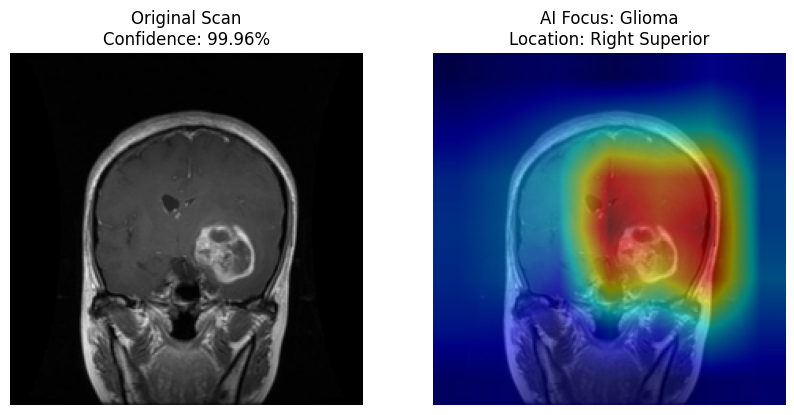

Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



📄 CLINICAL IMPRESSION:
Clinical Impression:

The MRI findings indicate the presence of a glioma located in the right superior region of the brain, as evidenced by the volumetric analysis which reveals a significant mass effect with a volume of 7761.0 pixels. This finding necessitates further evaluation and management in accordance with current clinical guidelines for gliomas.
--------------------------------------------------
🔍 Analyzing MENINGIOMA Sample: m3 (35).jpg


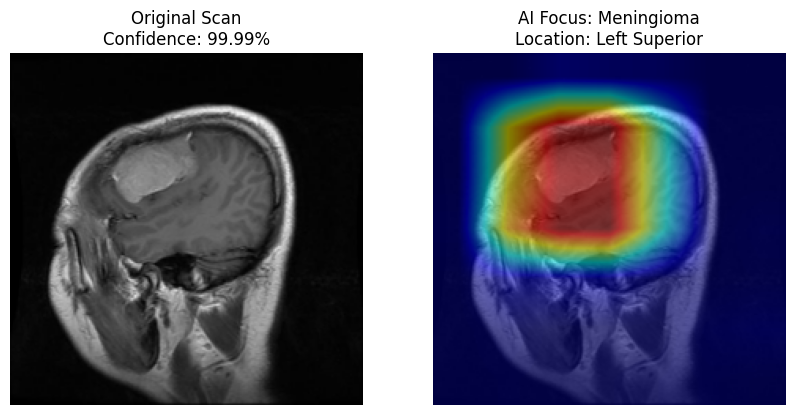


📄 CLINICAL IMPRESSION:
Clinical Impression:

The MRI findings indicate the presence of a meningioma located at the left superior region, as per the provided coordinates (89, 80). The volumetric analysis reveals a significant mass effect with a volume of 7372.5 pixels. This suggests a substantial lesion that may be exerting pressure on adjacent brain structures. Further evaluation and management should be considered to assess the impact on neurological function and to determine the appropriate therapeutic approach.
--------------------------------------------------
🔍 Analyzing NOTUMOR Sample: image (8).jpg


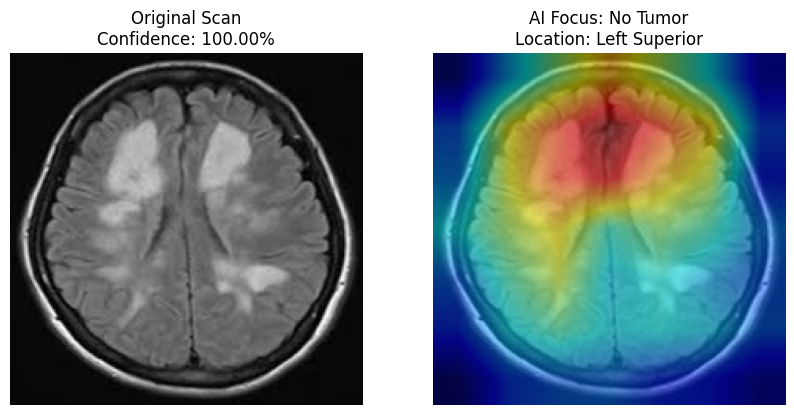

Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



📄 CLINICAL IMPRESSION:
Neuro-imaging suggests no significant focal lesions or abnormalities in this scan.
--------------------------------------------------
🔍 Analyzing PITUITARY Sample: Tr-pi_0016.jpg


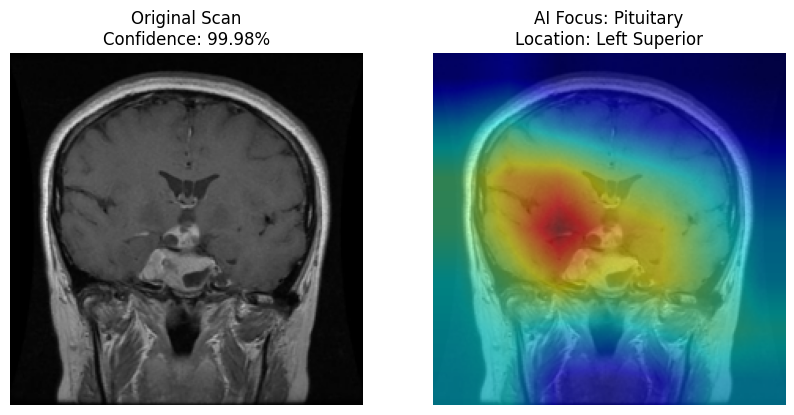


📄 CLINICAL IMPRESSION:
Clinical Impression:

The MRI findings indicate the presence of a significant pituitary mass located at the left superior aspect of the sella turcica, as evidenced by the volumetric analysis which reveals a mass effect with a volume of 6801.0 pixels. This sizeable lesion may be indicative of a pituitary adenoma or other space-occupying process. Given the mass's location and size, it is likely to be exerting pressure on the normal pituitary gland and potentially impacting the optic chiasm, which could lead to visual disturbances. Further endocrinological evaluation and a detailed
--------------------------------------------------


In [ ]:
val_path = '/content/dataset/Val'
actual_folders = os.listdir(val_path)

# Map names (Standard -> Folder)
class_map = {std.lower().replace(" ", ""): f for std in class_names
             for f in actual_folders if std.lower().replace(" ", "") in f.lower().replace(" ", "")}

print(f"Using Mapping: {class_map}\n")

for std_name, folder in class_map.items():
    current_class_path = Path(val_path) / folder
    images = []
    for ext in ['*.jpg', '*.png', '*.jpeg']:
        images.extend(list(current_class_path.glob(f"**/{ext}")))

    if images:
        selected_sample = str(random.choice(images))
        print(f"🔍 Analyzing {std_name.upper()} Sample: {os.path.basename(selected_sample)}")
        run_diagnosis(selected_sample) # This will now be 50x faster!
    else:
        print(f"❌ Could not find images in {current_class_path}")

advanced logic

In [ ]:
def build_advanced_clinical_prompt(class_name, geometry):
    # 1. Staging Logic (Heuristic based on area)
    # In 224x224, > 5000px is roughly 10% of the total area (Significant/Late)
    stage = "Late Stage (Infiltrative)" if geometry['area'] > 5000 else "Initial/Early Stage (Focal)"

    # 2. Treatment Protocols (Doctor's 'What to do')
    protocols = {
        "Glioma": "Immediate neurosurgical consultation for biopsy/resection. Consider MRI spectroscopy.",
        "Meningioma": "Monitor mass effect. Neurosurgical review for possible craniotomy if symptomatic.",
        "Pituitary": "Endocrine panel required (Prolactin, GH, Cortisol). Refer to Ophthalmology for visual field mapping.",
        "No Tumor": "Routine follow-up as per standard screening protocols."
    }

    advice = protocols.get(class_name, "Further clinical correlation required.")

    # 3. The Final Prompt for Phi-3
    prompt = f"""<|system|>
You are a Senior Neuro-Radiologist. Generate a professional report including 'Impression' and 'Recommendations'.
DATA:
- Classification: {class_name}
- Stage: {stage}
- Location: {geometry['quadrant']} (Coords: {geometry['x']}, {geometry['y']})
- Volumetric Proxy: {geometry['area']} pixels
- Clinical Protocol: {advice}
<|end|>
<|user|>
Write a formal report. Include a section named 'PHYSICIAN ADVICE'.
<|end|>
<|assistant|>"""

    # 4. Meta-Prompt for Larger LLMs (The 'Future Value' feature)
    meta_prompt = f"[SYSTEM_TRANSFER]: Patient shows {class_name} at {geometry['quadrant']} ({geometry['x']},{geometry['y']}). " \
                  f"Measured size is {geometry['area']}px indicating {stage}. Recommended: {advice}. " \
                  f"Analyze for surgical viability and potential neuro-anatomical risks."

    return prompt, meta_prompt

mega report

In [ ]:
def run_diagnosis_v2(image_path):
    # (Same Vision/Geometry steps as before...)
    raw_img = Image.open(image_path).convert('RGB')
    input_tensor = test_transform(raw_img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = master_model(input_tensor)
        probabilities = F.softmax(outputs, dim=1)
        conf, pred = torch.max(probabilities, 1)
        class_name = class_names[pred.item()]

    grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0, :]
    geo = extract_tumor_geometry(grayscale_cam)

    # --- NEW LOGIC ---
    if class_name != "No Tumor" and geo:
        phi_prompt, meta_prompt = build_advanced_clinical_prompt(class_name, geo)
        report = llm_pipeline(phi_prompt, max_new_tokens=250, do_sample=False)[0]['generated_text']
        report = report.split("<|assistant|>")[-1].strip()
    else:
        report = "Impression: Normal Study. No focal abnormalities detected."
        meta_prompt = "Normal Study."

    # Visualization
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1); plt.imshow(raw_img.resize((224,224))); plt.axis('off')
    plt.subplot(1, 2, 2)
    visualization = show_cam_on_image(np.array(raw_img.resize((224,224)))/255.0, grayscale_cam, use_rgb=True)
    plt.imshow(visualization); plt.axis('off')
    plt.show()

    print(f"📄 FINAL REPORT:\n{report}")
    print(f"\n🔗 META-PROMPT FOR GPT-4/RESEARCH:\n{meta_prompt}")
    print("-" * 50)

🧪 TESTING GLIOMA...


Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


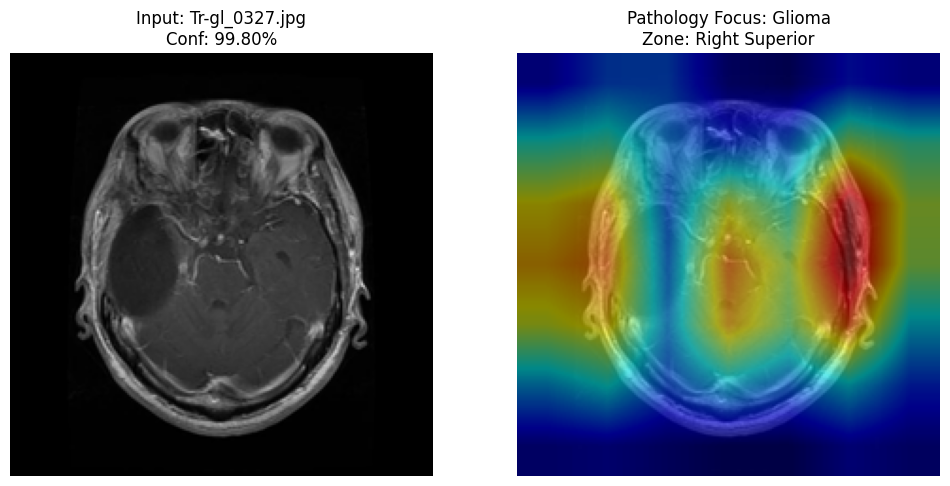

Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



📄 OFFICIAL RADIOLOGY REPORT
**Neuroimaging Report**

**Patient:** [Patient Name]

**Date:** [Date of Report]

**Referring Physician:** [Referring Physician's Name]

**Radiologist:** [Your Name]

**Imaging Modality:** MRI

**Findings:**

The MRI of the brain was performed to evaluate a focal lesion in the right superior region. The lesion is classified as a glioma based on its imaging characteristics. The lesion is localized to the right superior region with coordinates (176, 104). The volumetric analysis indicates a lesion size of 4278.0 pixels.

**Impression:**

The imaging findings are suggestive of an initial or early-stage focal glioma in the right superior region of the brain. The lesion's size and characteristics warrant further investigation to determine the exact nature and grade of the glioma.

**Recommendations:**

1. Immediate neurosurgical consultation for biopsy

🔗 RESEARCH META-PROMPT (FOR GPT-4/CLAUDE/GEMINI):
[SYSTEM_TRANSFER]: Patient shows Glioma at Right Superior (1

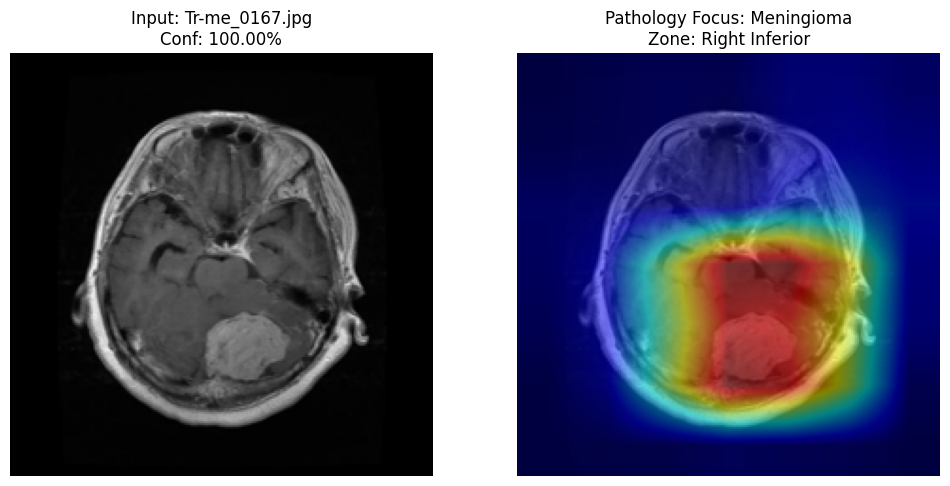


📄 OFFICIAL RADIOLOGY REPORT
**Radiological Report on Meningioma**

**Patient Information:**
[Patient Name], [Patient ID]

**Date of Report:** [Date]

**Radiologist:**
[Radiologist Name], [Title]

**Clinical Information:**
The patient has been diagnosed with a meningioma located in the right inferior region of the brain. The tumor is classified as a late-stage infiltrative meningioma.

**Imaging Findings:**
The computed tomography (CT) scan and magnetic resonance imaging (MRI) have revealed a mass with a volumetric proxy of 7361.5 pixels. The mass is situated at coordinates (130, 141) in the right inferior region of the brain.

**Impression:**
The imaging findings are consistent with a late-stage infiltrative meningioma. The size and location of the tumor suggest a potential for mass effect and associated symptoms.

**Recommendations:**
1. Monitor the mass effect

🔗 RESEARCH META-PROMPT (FOR GPT-4/CLAUDE/GEMINI):
[SYSTEM_TRANSFER]: Patient shows Meningioma at Right Inferior (130,141). 

UnidentifiedImageError: cannot identify image file '/content/dataset/Val/No Tumor/labels/Tr-no_0321.txt'

In [ ]:
def run_full_clinical_diagnosis(image_path):
    """
    Final Pipeline:
    1. Vision Model Classifies (TripleFusion)
    2. OpenCV Ruler Measures (Geometry)
    3. Logic Engine Stages (Early/Late)
    4. Phi-3 Writes the Doctor's Report
    5. Meta-Prompt Exports for Research
    """
    # 1. Processing
    raw_img = Image.open(image_path).convert('RGB')
    input_tensor = test_transform(raw_img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = master_model(input_tensor)
        probabilities = F.softmax(outputs, dim=1)
        conf, pred = torch.max(probabilities, 1)
        class_name = class_names[pred.item()]

    # 2. Geometry & Staging
    grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0, :]
    geo = extract_tumor_geometry(grayscale_cam)

    # 3. Generating Advanced Report
    if class_name != "No Tumor" and geo:
        # Get both the Phi-3 prompt and the high-fidelity Meta-Prompt
        phi_prompt, meta_prompt = build_advanced_clinical_prompt(class_name, geo)

        # Inference with slightly higher tokens for detailed advice
        report = llm_pipeline(phi_prompt, max_new_tokens=250, do_sample=False)[0]['generated_text']
        report = report.split("<|assistant|>")[-1].strip()
    else:
        report = "IMPRESSION: Normal neuro-imaging. No evidence of space-occupying lesions."
        meta_prompt = "STATUS: Normal Study. No focal findings."

    # 4. Professional Visualization
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(raw_img.resize((224, 224)))
    plt.title(f"Input: {os.path.basename(image_path)}\nConf: {conf.item():.2%}")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    visualization = show_cam_on_image(np.array(raw_img.resize((224, 224)))/255.0, grayscale_cam, use_rgb=True)
    plt.imshow(visualization)
    plt.title(f"Pathology Focus: {class_name}\nZone: {geo['quadrant'] if geo else 'N/A'}")
    plt.axis('off')

    plt.show()

    print(f"\n" + "="*60)
    print(f"📄 OFFICIAL RADIOLOGY REPORT")
    print("="*60)
    print(report)
    print("\n" + "="*60)
    print(f"🔗 RESEARCH META-PROMPT (FOR GPT-4/CLAUDE/GEMINI):")
    print(meta_prompt)
    print("="*60 + "\n")

# --- TEST THE MAPPING AGAIN ---
for std_name, folder in class_map.items():
    current_class_path = Path(val_path) / folder
    images = list(current_class_path.glob("**/Tr-*")) + list(current_class_path.glob("**/m*")) # Optimized for your filenames

    if images:
        selected_sample = str(random.choice(images))
        print(f"🧪 TESTING {std_name.upper()}...")
        run_full_clinical_diagnosis(selected_sample)

🚀 Starting Final Clinical Evaluation...
Using Mapping: {'glioma': 'Glioma', 'meningioma': 'Meningioma', 'notumor': 'No Tumor', 'pituitary': 'Pituitary'}

🧪 TESTING GLIOMA...
📂 File: Tr-gl_0933.jpg


Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


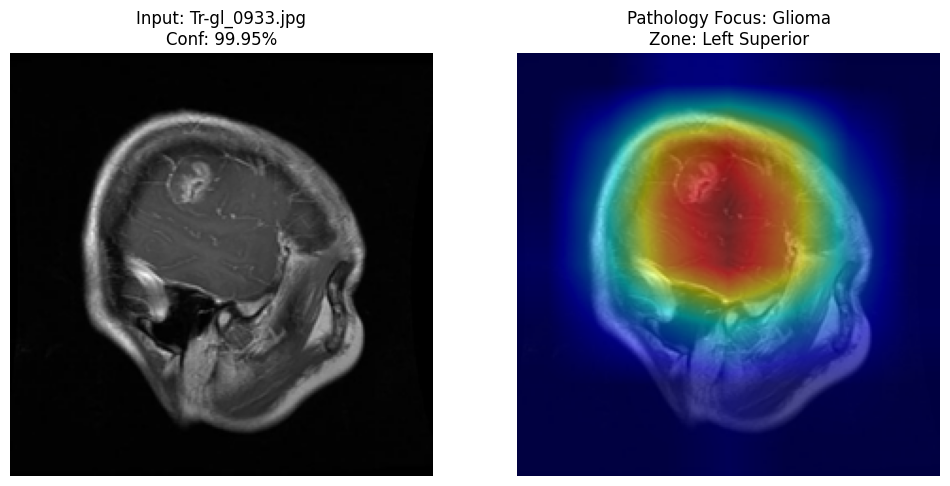

Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



📄 OFFICIAL RADIOLOGY REPORT
**Neuroimaging Report**

**Patient:** [Patient Name]

**Date:** [Date of Report]

**Referring Physician:** [Referring Physician's Name]

**Radiologist:** [Your Name]

**Imaging Modality:** MRI

**Findings:**

The MRI of the brain was performed to evaluate a lesion in the left superior region. The lesion is classified as a glioma, which is a type of brain tumor originating from glial cells. The imaging findings are suggestive of a late-stage infiltrative glioma, which indicates that the tumor has likely invaded surrounding brain tissue.

The lesion is located at coordinates (109, 84) in the left superior region of the brain. The volumetric analysis of the lesion indicates a size of approximately 6761.5 pixels, which correlates with a significant mass effect.

**Impression:**

The MRI findings are consistent with a late-stage infiltrative glioma in

🔗 RESEARCH META-PROMPT (FOR GPT-4/CLAUDE/GEMINI):
[SYSTEM_TRANSFER]: Patient shows Glioma at Left Superior (109

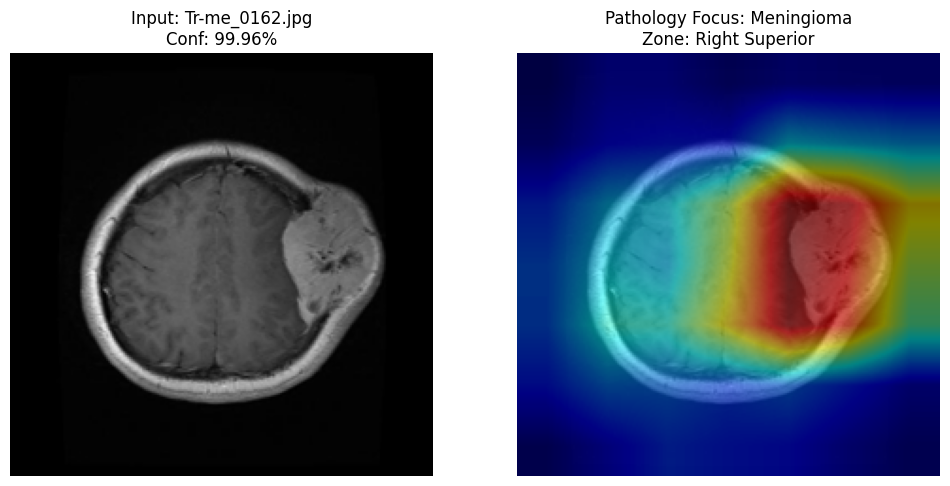


📄 OFFICIAL RADIOLOGY REPORT
**Neuroimaging Report**

**Patient:** [Patient Name]

**Date:** [Date of Report]

**Radiologist:** [Your Name]

**Imaging Modality:** [Modality Used]

**Findings:**

The patient has been identified to have a meningioma located at the right superior region of the brain, with coordinates at approximately 159, 108. The tumor is classified as a late-stage infiltrative meningioma, which suggests a more aggressive growth pattern and potential for increased intracranial pressure.

The volumetric analysis indicates a tumor size of 8307.0 pixels. This measurement should be correlated with the patient's head size and the imaging modality used to provide a more accurate assessment of the tumor volume.

**Impression:**

The imaging findings are consistent with a diagnosis of a late-stage infiltrative meningioma at the right superior location. Given the size and aggressive nature of the tumor, there

🔗 RESEARCH META-PROMPT (FOR GPT-4/CLAUDE/GEMINI):
[SYSTEM_TRANSFER]: P

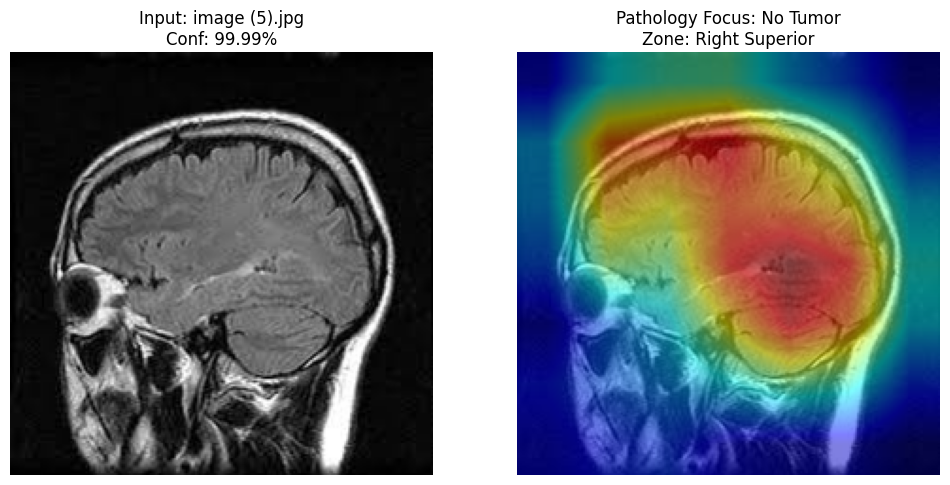

Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



📄 OFFICIAL RADIOLOGY REPORT
IMPRESSION: Normal neuro-imaging. No evidence of space-occupying lesions.

🔗 RESEARCH META-PROMPT (FOR GPT-4/CLAUDE/GEMINI):
STATUS: Normal Study. No focal findings.

🧪 TESTING PITUITARY...
📂 File: Tr-pi_0722.jpg


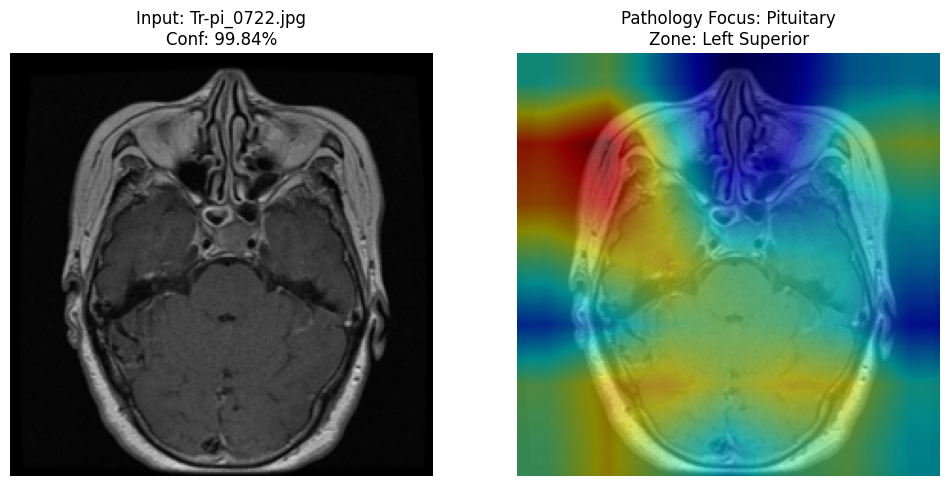


📄 OFFICIAL RADIOLOGY REPORT
**Neuroimaging Report: Pituitary Gland Assessment**


**Patient Information:**

[Patient Name], [Patient ID]


**Date of Examination:** [Date]


**Examination Findings:**


**Impression:**

The neuroimaging of the pituitary gland reveals an infiltrative lesion located in the left superior region, corresponding to the coordinates (41, 70). The lesion's volumetric analysis indicates a size of approximately 6044.5 pixels, which suggests a significant mass effect. Given the location and the size of the lesion, a late-stage classification is appropriate.


**Recommendations:**

1. An endocrine panel, including measurements of Prolactin, Growth Hormone (GH), and Cortisol levels, is advised to assess the functional impact of the lesion on the pituitary gland.

2. A referral to Ophthalmology is recommended for comprehensive visual field mapping

🔗 RESEARCH META-PROMPT (FOR GPT-4/CLAUDE/GEMINI):
[SYSTEM_TRANSFER]: Patient shows Pituitary at Left Superior (41,70). Me

In [ ]:
import os
import random
from pathlib import Path
import matplotlib.pyplot as plt

# --- 1. SET THE PATHS ---
val_path = '/content/dataset/Val'
actual_folders = os.listdir(val_path)

# --- 2. THE SMART MAPPING LOGIC ---
class_map = {std.lower().replace(" ", ""): f for std in class_names
             for f in actual_folders if std.lower().replace(" ", "") in f.lower().replace(" ", "")}

print(f"🚀 Starting Final Clinical Evaluation...")
print(f"Using Mapping: {class_map}\n")

# --- 3. THE LOOP ---
for std_name, folder in class_map.items():
    current_class_path = Path(val_path) / folder

    # Strictly find valid image files and EXCLUDE 'labels' directories
    valid_images = []
    for ext in ['*.jpg', '*.jpeg', '*.png']:
        found_files = list(current_class_path.glob(f"**/{ext}"))
        # Filter: Must be an image and MUST NOT be in a 'labels' subfolder
        valid_images.extend([f for f in found_files if "labels" not in str(f)])

    if valid_images:
        selected_sample = str(random.choice(valid_images))
        print(f"🧪 TESTING {std_name.upper()}...")
        print(f"📂 File: {os.path.basename(selected_sample)}")

        # Call your unified diagnostic function
        try:
            run_full_clinical_diagnosis(selected_sample)
        except Exception as e:
            print(f"❌ Error during diagnosis of {selected_sample}: {e}")
    else:
        print(f"⚠️ Skipping {std_name.upper()}: No valid image files found in {current_class_path}")

print("\n✅ Evaluation Cycle Complete.")

final with a save option

In [ ]:
import os
import matplotlib.pyplot as plt

def run_full_clinical_diagnosis_and_save(image_path, save_root):
    """
    Final Pipeline with Auto-Save functionality.
    Saves: 1. Combined JPG of the MRI/Heatmap
           2. TXT file of the Radiology Report & Meta-Prompt
    """
    # Create the directory if it doesn't exist
    if not os.path.exists(save_root):
        os.makedirs(save_root)
        print(f"📁 Created folder: {save_root}")

    # 1. Processing (Vision + Geometry)
    raw_img = Image.open(image_path).convert('RGB')
    input_tensor = test_transform(raw_img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = master_model(input_tensor)
        probabilities = F.softmax(outputs, dim=1)
        conf, pred = torch.max(probabilities, 1)
        class_name = class_names[pred.item()]

    grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0, :]
    geo = extract_tumor_geometry(grayscale_cam)

    # 2. Generating Advanced Report
    if class_name != "No Tumor" and geo:
        phi_prompt, meta_prompt = build_advanced_clinical_prompt(class_name, geo)
        report = llm_pipeline(phi_prompt, max_new_tokens=250, do_sample=False)[0]['generated_text']
        report = report.split("<|assistant|>")[-1].strip()
    else:
        report = "IMPRESSION: Normal neuro-imaging. No evidence of space-occupying lesions."
        meta_prompt = "STATUS: Normal Study. No focal findings."

    # 3. Save Visual Result
    fig = plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(raw_img.resize((224, 224)))
    plt.title(f"Input: {os.path.basename(image_path)}\nConf: {conf.item():.2%}")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    visualization = show_cam_on_image(np.array(raw_img.resize((224, 224)))/255.0, grayscale_cam, use_rgb=True)
    plt.imshow(visualization)
    plt.title(f"Pathology Focus: {class_name}\nZone: {geo['quadrant'] if geo else 'N/A'}")
    plt.axis('off')

    # Save the plot
    base_filename = os.path.splitext(os.path.basename(image_path))[0]
    img_save_path = os.path.join(save_root, f"{base_filename}_result.jpg")
    plt.savefig(img_save_path, bbox_inches='tight')
    plt.close(fig) # Close to save memory

    # 4. Save Text Report
    text_save_path = os.path.join(save_root, f"{base_filename}_report.txt")
    with open(text_save_path, "w") as f:
        f.write(f"OFFICIAL RADIOLOGY REPORT\n")
        f.write("="*30 + "\n")
        f.write(report)
        f.write("\n\n" + "="*30 + "\n")
        f.write(f"RESEARCH META-PROMPT:\n{meta_prompt}")

    print(f"✅ Saved results for {base_filename} to {save_root}")

# --- EXECUTION WITH AUTO-SAVE ---
SAVE_DIR = '/content/drive/MyDrive/Code for paper/finetuned results'

for std_name, folder in class_map.items():
    current_class_path = Path(val_path) / folder
    valid_images = []
    for ext in ['*.jpg', '*.jpeg', '*.png']:
        found_files = list(current_class_path.glob(f"**/{ext}"))
        valid_images.extend([f for f in found_files if "labels" not in str(f)])

    if valid_images:
        selected_sample = str(random.choice(valid_images))
        run_full_clinical_diagnosis_and_save(selected_sample, SAVE_DIR)

📁 Created folder: /content/drive/MyDrive/Code for paper/finetuned results


Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


✅ Saved results for gg (52) to /content/drive/MyDrive/Code for paper/finetuned results
✅ Saved results for Tr-me_0012 to /content/drive/MyDrive/Code for paper/finetuned results


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


✅ Saved results for image(308) to /content/drive/MyDrive/Code for paper/finetuned results
✅ Saved results for Tr-pi_1436 to /content/drive/MyDrive/Code for paper/finetuned results
